# MIT-BIH Context-Aware ECG Beat Dataset Creator

## Objective
Create a context-aware ECG beat dataset using temporal beat windows for subject-independent training and evaluation.

## Key Features
1. **Context Windows**: 7 beats (3 previous + 1 center + 3 subsequent)
2. **Record-Wise Split**: No patient leakage between train/val/test
3. **R-Peak Detection**: Using Pan-Tompkins algorithm
4. **Fixed Beat Length**: 200 samples per beat (90 before R-peak, 110 after)
5. **Binary Classification**: N = Normal (0), any other = Abnormal (1)

## Constraints
- Skip record 119 entirely (reserved for live testing)
- Beat-wise random splitting is NOT allowed
- Context window strictly enforced

In [1]:
!rm -rf /kaggle/working/*

## STEP 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import os
import json
from glob import glob
from scipy.signal import resample, butter, filtfilt, find_peaks
import warnings
warnings.filterwarnings('ignore')

# Configuration
BEAT_LENGTH = 200  # Fixed samples per beat
PRE_R_SAMPLES = 90  # Samples before R-peak
POST_R_SAMPLES = 110  # Samples after R-peak
CONTEXT_WINDOW_SIZE = 7  # 3 previous + 1 center + 3 subsequent
SAMPLING_RATE = 360  # MIT-BIH sampling rate (Hz)
EXCLUDE_RECORDS = ['119']  # Reserve for live testing
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print('Configuration:')
print(f'  Beat length: {BEAT_LENGTH} samples')
print(f'  Pre-R samples: {PRE_R_SAMPLES}')
print(f'  Post-R samples: {POST_R_SAMPLES}')
print(f'  Context window size: {CONTEXT_WINDOW_SIZE} beats')
print(f'  Sampling rate: {SAMPLING_RATE} Hz')
print(f'  Excluded records: {EXCLUDE_RECORDS}')

Configuration:
  Beat length: 200 samples
  Pre-R samples: 90
  Post-R samples: 110
  Context window size: 7 beats
  Sampling rate: 360 Hz
  Excluded records: ['119']


## STEP 2: Define Data Paths

In [3]:
KAGGLE_PATH = '/kaggle/input/mitbih-database/'

if os.path.exists(KAGGLE_PATH):
    DATA_PATH = KAGGLE_PATH
    print(f'Using Kaggle path: {DATA_PATH}')
else:
    raise FileNotFoundError('No valid data path found!')

# List all CSV files (ECG signals)
signal_files = sorted(glob(os.path.join(DATA_PATH, '*.csv')))
print(f'\nFound {len(signal_files)} signal files')

# Filter out excluded records
signal_files = [f for f in signal_files if not any(excl in os.path.basename(f) for excl in EXCLUDE_RECORDS)]
print(f'After excluding {EXCLUDE_RECORDS}: {len(signal_files)} files')

# List available records
record_names = [os.path.basename(f).replace('.csv', '') for f in signal_files]
print(f'\nAvailable records: {record_names}')

Using Kaggle path: /kaggle/input/mitbih-database/

Found 48 signal files
After excluding ['119']: 47 files

Available records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


## STEP 3: Parse Annotation File

In [4]:
def parse_annotations(annotation_file):
    annotations = []
    
    try:
        with open(annotation_file, 'r') as f:
            lines = f.readlines()
        
        # Skip header line
        for line in lines[1:]:
            parts = line.strip().split()
            if len(parts) >= 3:
                try:
                    sample_idx = int(parts[1])
                    beat_type = parts[2]
                    
                    # Skip non-beat annotations (rhythm markers, etc.)
                    # Valid beat types: N, L, R, B, A, a, J, S, V, r, F, e, j, n, E, /, f, Q, ?
                    if beat_type not in ['+', '~', '|', 's', 'T', '*', 'D', '=', '"', '@']:
                        annotations.append((sample_idx, beat_type))
                except (ValueError, IndexError):
                    continue
    except Exception as e:
        print(f'Error parsing {annotation_file}: {e}')
        
    return annotations


# Test parsing
test_ann_file = os.path.join(DATA_PATH, '100annotations.txt')
if os.path.exists(test_ann_file):
    test_annotations = parse_annotations(test_ann_file)
    print(f'Test parse: {len(test_annotations)} annotations from 100annotations.txt')
    print(f'First 5 annotations: {test_annotations[:5]}')

Test parse: 2273 annotations from 100annotations.txt
First 5 annotations: [(77, 'N'), (370, 'N'), (662, 'N'), (946, 'N'), (1231, 'N')]


## STEP 4: R-Peak Detection (Pan-Tompkins Algorithm)

In [5]:
def bandpass_filter(signal, lowcut=5.0, highcut=15.0, fs=360, order=1):
    #apply bandpass filter to ECG signal.
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)


def detect_r_peaks_pan_tompkins(signal, fs=360):

    # Step 4.1: Bandpass filter
    filtered = bandpass_filter(signal, 5.0, 15.0, fs)
    
    # Step 4.2: Differentiate
    diff = np.diff(filtered)
    
    # Step 4.3: Square
    squared = diff ** 2
    
    # Step 4.4: Moving window integration (150ms window)
    window_size = int(0.150 * fs)
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode='same')
    
    # Step 4.5: Find peaks with adaptive thresholding
    # Use minimum distance between peaks (200ms = 0.2s * fs samples)
    min_distance = int(0.2 * fs)
    
    # Dynamic threshold: 0.5 * max of rolling mean
    threshold = 0.3 * np.max(integrated)
    
    peaks, _ = find_peaks(integrated, height=threshold, distance=min_distance)
    
    # Refine peaks: find actual R-peak in original signal (max in small window)
    refined_peaks = []
    search_window = int(0.05 * fs)  # 50ms window
    
    for peak in peaks:
        start = max(0, peak - search_window)
        end = min(len(signal), peak + search_window)
        local_max = start + np.argmax(signal[start:end])
        refined_peaks.append(local_max)
    
    return np.array(refined_peaks)


print('R-peak detection functions defined (Pan-Tompkins algorithm)')

R-peak detection functions defined (Pan-Tompkins algorithm)


## STEP 5: Beat Extraction Functions

In [6]:
def extract_beat(signal, r_peak_idx, pre_samples=PRE_R_SAMPLES, post_samples=POST_R_SAMPLES):
    beat_length = pre_samples + post_samples
    start_idx = r_peak_idx - pre_samples
    end_idx = r_peak_idx + post_samples
    
    # Handle edge cases with zero padding
    if start_idx < 0:
        pad_before = -start_idx
        beat = np.zeros(beat_length, dtype=np.float32)
        available = signal[:end_idx]
        beat[pad_before:pad_before + len(available)] = available
    elif end_idx > len(signal):
        beat = np.zeros(beat_length, dtype=np.float32)
        available = signal[start_idx:]
        beat[:len(available)] = available
    else:
        beat = signal[start_idx:end_idx].astype(np.float32)
    
    return beat


def find_annotation_for_peak(r_peak_idx, annotations, tolerance=20):
    best_match = None
    best_distance = tolerance + 1
    
    for sample_idx, beat_type in annotations:
        distance = abs(sample_idx - r_peak_idx)
        if distance < best_distance:
            best_distance = distance
            best_match = beat_type
    
    return best_match if best_distance <= tolerance else None


print('Beat extraction functions defined')

Beat extraction functions defined


### Visualization: Original ECG Signal with Annotations

Plot a sample of original ECG data showing ~15 beats in the middle of a random record:
1. **Multi-color annotations**: N (Normal) is blue, other annotation types have random colors
2. **Binary format**: Normal is blue, Abnormal is red

Visualizing record: 221
Total annotations: 2427
Unique beat types: ['N', 'V']
Selected beats 1206 to 1220 (middle 15 beats)


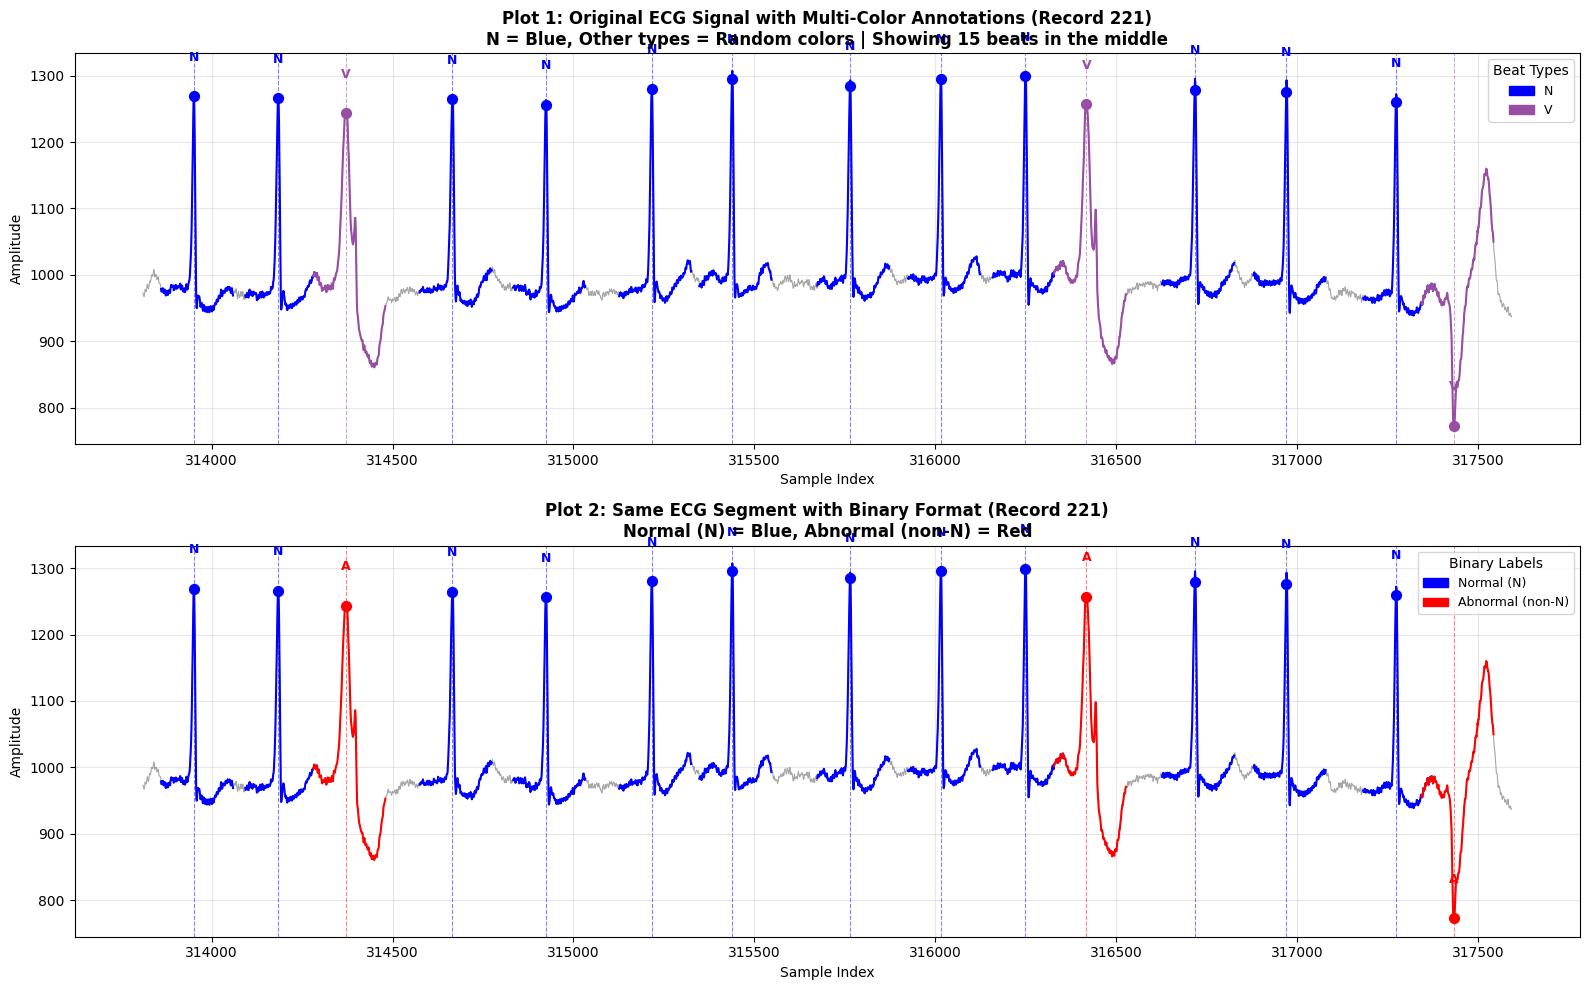


Visualization saved to: ecg_signal_annotations_visualization.png


In [7]:
# Visualization: Original ECG Signal with Annotations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(RANDOM_STATE)

# Pick a random record that has annotations
sample_record = np.random.choice(record_names)
sample_signal_file = os.path.join(DATA_PATH, f'{sample_record}.csv')
sample_annotation_file = os.path.join(DATA_PATH, f'{sample_record}annotations.txt')

print(f'Visualizing record: {sample_record}')

# Load signal
sample_df = pd.read_csv(sample_signal_file)
sample_df.columns = sample_df.columns.str.strip().str.strip("'")
if 'MLII' in sample_df.columns:
    sample_signal = sample_df['MLII'].values.astype(float)
elif sample_df.shape[1] > 1:
    sample_signal = sample_df.iloc[:, 1].values.astype(float)
else:
    sample_signal = sample_df.iloc[:, 0].values.astype(float)

# Parse annotations
sample_annotations = parse_annotations(sample_annotation_file)
print(f'Total annotations: {len(sample_annotations)}')

# Get unique beat types
unique_beat_types = list(set([ann[1] for ann in sample_annotations]))
print(f'Unique beat types: {unique_beat_types}')

# Select 15 beats in the middle
n_beats_to_plot = 15
total_beats = len(sample_annotations)
start_beat_idx = (total_beats - n_beats_to_plot) // 2
end_beat_idx = start_beat_idx + n_beats_to_plot

selected_annotations = sample_annotations[start_beat_idx:end_beat_idx]
print(f'Selected beats {start_beat_idx} to {end_beat_idx-1} (middle {n_beats_to_plot} beats)')

# Get signal range for selected beats (with some padding)
start_sample = max(0, selected_annotations[0][0] - PRE_R_SAMPLES - 50)
end_sample = min(len(sample_signal), selected_annotations[-1][0] + POST_R_SAMPLES + 50)
signal_segment = sample_signal[start_sample:end_sample]

# Create color map for annotations (N is blue, others are random)
np.random.seed(42)  # For reproducibility
color_map = {}
for bt in unique_beat_types:
    if bt == 'N':
        color_map[bt] = 'blue'
    else:
        color_map[bt] = plt.cm.Set1(np.random.random())

# Create figure with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Multi-color annotations (N=blue, others=random colors)
ax1 = axes[0]
x_axis = np.arange(start_sample, end_sample)
ax1.plot(x_axis, signal_segment, 'gray', linewidth=0.8, alpha=0.7, label='ECG Signal')

# Plot each beat segment with its annotation color
for ann_idx, (sample_idx, beat_type) in enumerate(selected_annotations):
    beat_start = sample_idx - PRE_R_SAMPLES
    beat_end = sample_idx + POST_R_SAMPLES
    
    # Clip to signal segment range
    plot_start = max(beat_start, start_sample)
    plot_end = min(beat_end, end_sample)
    
    if plot_start < plot_end:
        x_range = np.arange(plot_start, plot_end)
        y_range = sample_signal[plot_start:plot_end]
        ax1.plot(x_range, y_range, color=color_map[beat_type], linewidth=1.5)
        
        # Mark R-peak
        if start_sample <= sample_idx < end_sample:
            ax1.axvline(x=sample_idx, color=color_map[beat_type], linestyle='--', alpha=0.5, linewidth=0.8)
            ax1.scatter([sample_idx], [sample_signal[sample_idx]], color=color_map[beat_type], s=50, zorder=5)
            ax1.text(sample_idx, sample_signal[sample_idx] + 0.1 * (np.max(signal_segment) - np.min(signal_segment)),
                    beat_type, ha='center', fontsize=9, fontweight='bold', color=color_map[beat_type])

# Create legend for Plot 1
legend_patches = [mpatches.Patch(color=color_map[bt], label=f'{bt}') for bt in sorted(color_map.keys())]
ax1.legend(handles=legend_patches, loc='upper right', title='Beat Types', fontsize=9)
ax1.set_title(f'Plot 1: Original ECG Signal with Multi-Color Annotations (Record {sample_record})\n'
              f'N = Blue, Other types = Random colors | Showing {n_beats_to_plot} beats in the middle',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Sample Index', fontsize=10)
ax1.set_ylabel('Amplitude', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Binary format (Normal=blue, Abnormal=red)
ax2 = axes[1]
ax2.plot(x_axis, signal_segment, 'gray', linewidth=0.8, alpha=0.7, label='ECG Signal')

binary_color_map = {0: 'blue', 1: 'red'}
binary_labels = {0: 'Normal (N)', 1: 'Abnormal (non-N)'}

for ann_idx, (sample_idx, beat_type) in enumerate(selected_annotations):
    binary_label = 0 if beat_type == 'N' else 1
    color = binary_color_map[binary_label]
    
    beat_start = sample_idx - PRE_R_SAMPLES
    beat_end = sample_idx + POST_R_SAMPLES
    
    plot_start = max(beat_start, start_sample)
    plot_end = min(beat_end, end_sample)
    
    if plot_start < plot_end:
        x_range = np.arange(plot_start, plot_end)
        y_range = sample_signal[plot_start:plot_end]
        ax2.plot(x_range, y_range, color=color, linewidth=1.5)
        
        if start_sample <= sample_idx < end_sample:
            ax2.axvline(x=sample_idx, color=color, linestyle='--', alpha=0.5, linewidth=0.8)
            ax2.scatter([sample_idx], [sample_signal[sample_idx]], color=color, s=50, zorder=5)
            label_text = 'N' if binary_label == 0 else 'A'
            ax2.text(sample_idx, sample_signal[sample_idx] + 0.1 * (np.max(signal_segment) - np.min(signal_segment)),
                    label_text, ha='center', fontsize=9, fontweight='bold', color=color)

# Create legend for Plot 2
legend_patches_binary = [mpatches.Patch(color=binary_color_map[k], label=binary_labels[k]) for k in [0, 1]]
ax2.legend(handles=legend_patches_binary, loc='upper right', title='Binary Labels', fontsize=9)
ax2.set_title(f'Plot 2: Same ECG Segment with Binary Format (Record {sample_record})\n'
              f'Normal (N) = Blue, Abnormal (non-N) = Red',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Sample Index', fontsize=10)
ax2.set_ylabel('Amplitude', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ecg_signal_annotations_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nVisualization saved to: ecg_signal_annotations_visualization.png')

## STEP 6: Process Single Record

In [8]:
def process_record(signal_file, annotation_file, use_detected_peaks=False):
    # Load signal (use MLII lead)
    try:
        signal_df = pd.read_csv(signal_file)
        signal_df.columns = signal_df.columns.str.strip().str.strip("'")
        
        if 'MLII' in signal_df.columns:
            signal = signal_df['MLII'].values.astype(float)
        elif signal_df.shape[1] > 1:
            signal = signal_df.iloc[:, 1].values.astype(float)
        else:
            signal = signal_df.iloc[:, 0].values.astype(float)
    except Exception as e:
        print(f'Error loading {signal_file}: {e}')
        return []
    
    # Parse annotations
    annotations = parse_annotations(annotation_file)
    if len(annotations) < 3:
        print(f'Too few annotations in {annotation_file}')
        return []
    
    # Use annotation R-peaks (more accurate than detection)
    r_peaks = np.array([ann[0] for ann in annotations])
    
    beats_data = []
    
    for i, r_peak_idx in enumerate(r_peaks):
        beat = extract_beat(signal, r_peak_idx)
        
        if beat is None or len(beat) != BEAT_LENGTH:
            continue
        
        # Get beat type from annotation
        beat_type = annotations[i][1]
        
        # Binary label: N = Normal (0), everything else = Abnormal (1)
        label = 0 if beat_type == 'N' else 1
        
        beats_data.append((beat, label, beat_type))
    
    return beats_data


print('Record processing function defined')

Record processing function defined


### Visualization: Single Record Beat Extraction (Step 6)

Visualize how individual beats are extracted from the same segment shown above.
This shows the `process_record` function output - extracted beats with their labels.

Visualizing record: 221
Record 221: Extracted 2427 beats
Visualizing beats 1206 to 1220


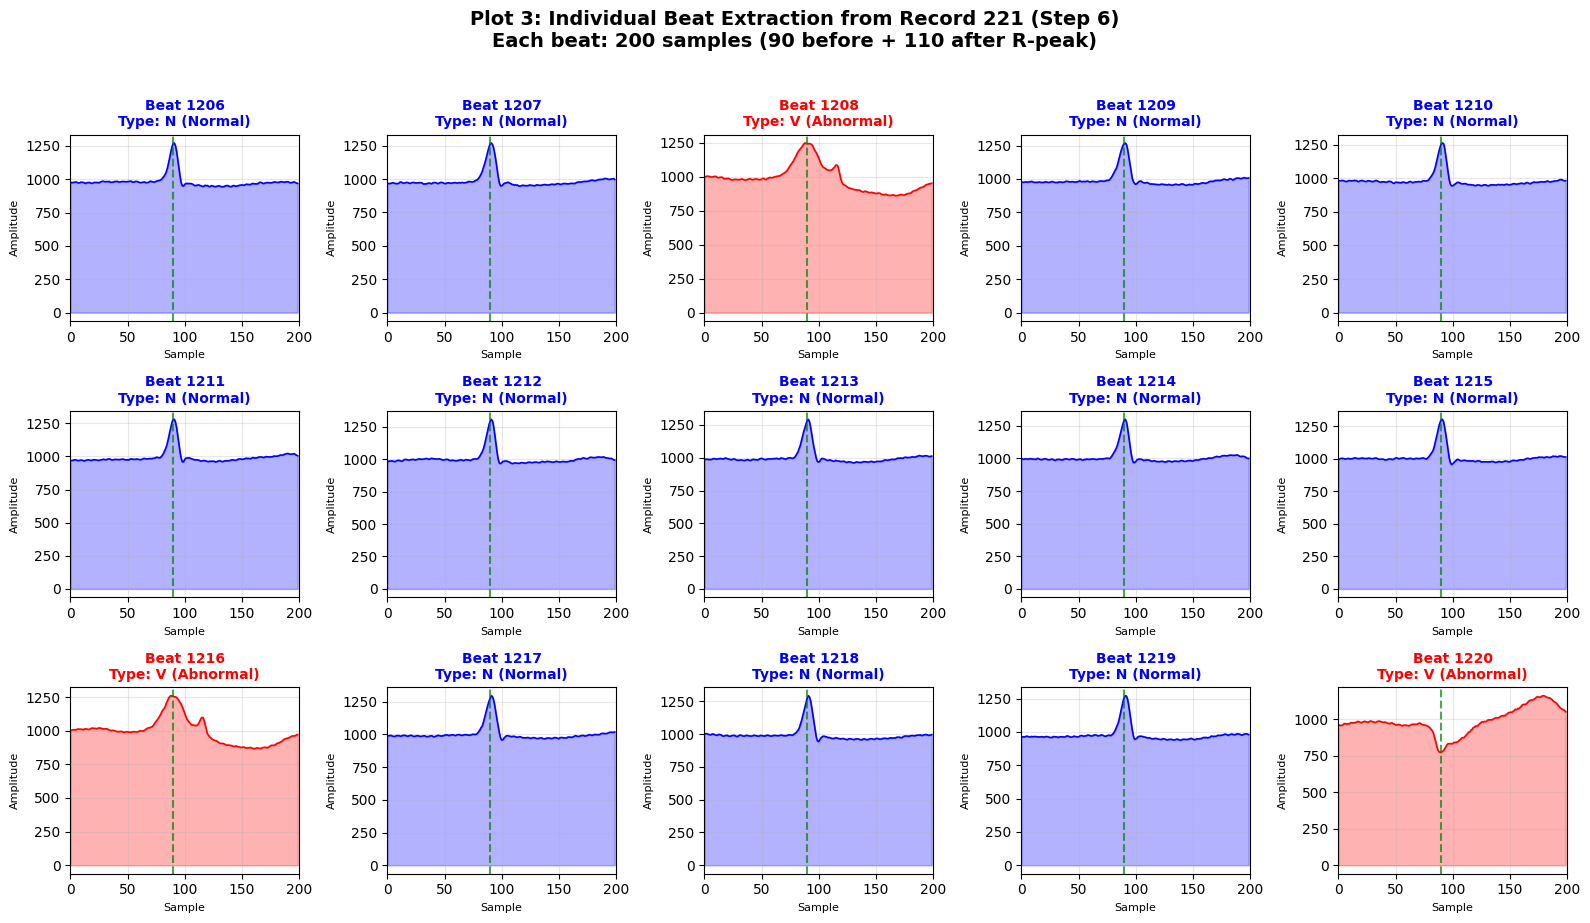


Visualization saved to: beat_extraction_visualization.png


In [9]:
# Visualization: Single Record Beat Extraction (Step 6)
# Use the same record and annotations from the previous visualization

# Check if variables from previous visualization exist, otherwise set them
if 'sample_record' not in dir() or 'sample_signal_file' not in dir():
    # Pick a random record that has annotations
    np.random.seed(RANDOM_STATE)
    sample_record = np.random.choice(record_names)
    sample_signal_file = os.path.join(DATA_PATH, f'{sample_record}.csv')
    sample_annotation_file = os.path.join(DATA_PATH, f'{sample_record}annotations.txt')
    
    # Load signal
    sample_df = pd.read_csv(sample_signal_file)
    sample_df.columns = sample_df.columns.str.strip().str.strip("'")
    if 'MLII' in sample_df.columns:
        sample_signal = sample_df['MLII'].values.astype(float)
    elif sample_df.shape[1] > 1:
        sample_signal = sample_df.iloc[:, 1].values.astype(float)
    else:
        sample_signal = sample_df.iloc[:, 0].values.astype(float)
    
    # Parse annotations
    sample_annotations = parse_annotations(sample_annotation_file)
    
    # Select 15 beats in the middle
    n_beats_to_plot = 15
    total_beats = len(sample_annotations)
    start_beat_idx = (total_beats - n_beats_to_plot) // 2
    end_beat_idx = start_beat_idx + n_beats_to_plot

print(f'Visualizing record: {sample_record}')

# Process the sample record to get beats
sample_beats_data = process_record(sample_signal_file, sample_annotation_file)
print(f'Record {sample_record}: Extracted {len(sample_beats_data)} beats')

# Get beats from the same middle portion
beats_to_visualize = sample_beats_data[start_beat_idx:end_beat_idx]
print(f'Visualizing beats {start_beat_idx} to {end_beat_idx-1}')

# Create figure showing extracted beats
n_cols = 5
n_rows = (n_beats_to_plot + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, (beat, label, beat_type) in enumerate(beats_to_visualize):
    if i >= len(axes):
        break
    ax = axes[i]
    
    # Color based on binary label
    color = 'blue' if label == 0 else 'red'
    label_text = 'Normal' if label == 0 else 'Abnormal'
    
    ax.plot(beat, color=color, linewidth=1.2)
    ax.axvline(x=PRE_R_SAMPLES, color='green', linestyle='--', alpha=0.7, label='R-peak')
    ax.fill_between(range(len(beat)), beat, alpha=0.3, color=color)
    
    ax.set_title(f'Beat {start_beat_idx + i}\nType: {beat_type} ({label_text})', 
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Sample', fontsize=8)
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.set_xlim(0, BEAT_LENGTH)
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Plot 3: Individual Beat Extraction from Record {sample_record} (Step 6)\n'
             f'Each beat: {BEAT_LENGTH} samples ({PRE_R_SAMPLES} before + {POST_R_SAMPLES} after R-peak)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('beat_extraction_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nVisualization saved to: beat_extraction_visualization.png')

## STEP 7: Context Window Construction

In [10]:
def create_context_windows(beats_data, window_size=CONTEXT_WINDOW_SIZE):

    if len(beats_data) < window_size:
        return []
    
    half_window = window_size // 2  # 3 beats before/after center
    context_windows = []
    
    for center_idx in range(half_window, len(beats_data) - half_window):
        # Extract beats in window
        window_beats = []
        for i in range(center_idx - half_window, center_idx + half_window + 1):
            beat, _, _ = beats_data[i]
            window_beats.append(beat)
        
        # Stack beats: shape (7, 200)
        context_window = np.stack(window_beats, axis=0)
        
        # Use center beat's label
        _, center_label, center_beat_type = beats_data[center_idx]
        
        context_windows.append((context_window, center_label, center_beat_type))
    
    return context_windows


print(f'Context window function defined (window_size={CONTEXT_WINDOW_SIZE})')

Context window function defined (window_size=7)


### Visualization: Context Window Construction (Step 7)

Visualize how context windows are constructed from the same beats shown in Step 6.
Each context window contains 7 beats: 3 previous + 1 center + 3 subsequent.

Record 221: Created 2421 context windows


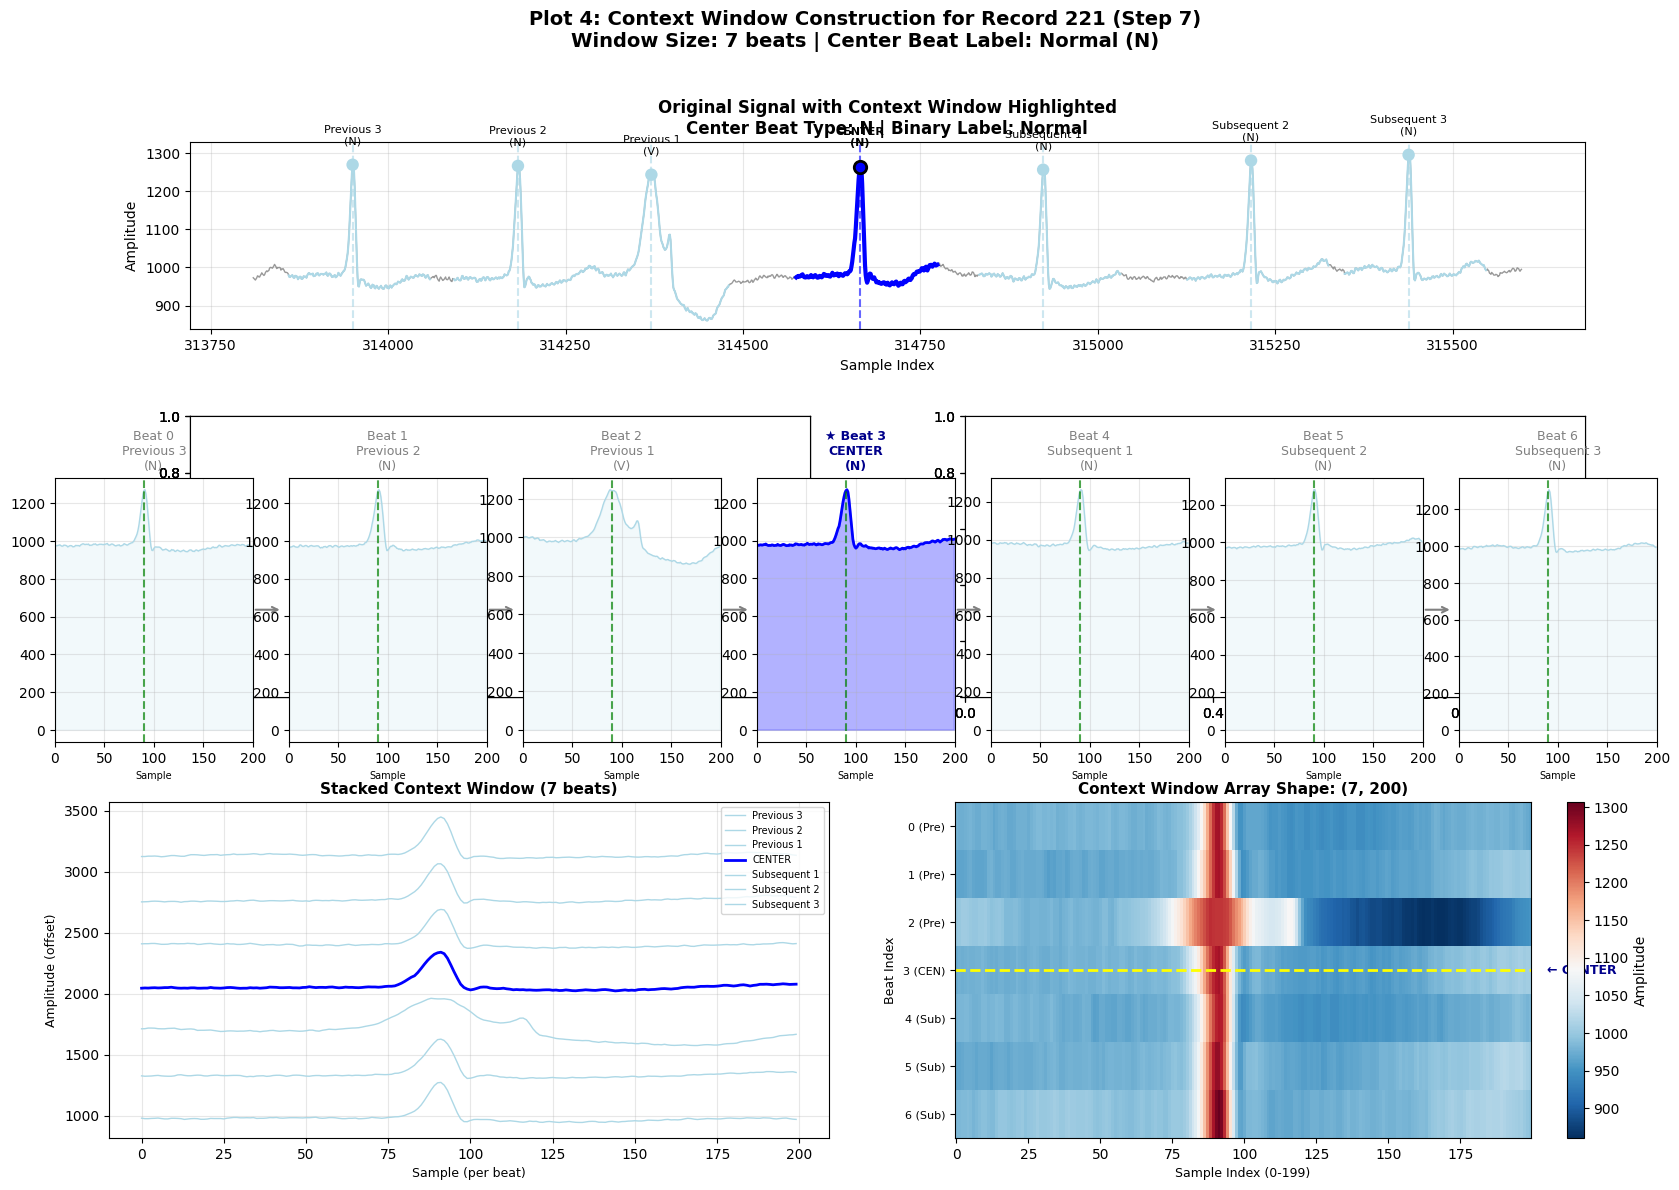


Visualization saved to: context_window_construction_visualization.png


In [11]:
# Visualization: Context Window Construction (Step 7)
# Ensure variables from previous visualizations exist

# Check if variables from previous visualization exist, otherwise set them
if 'sample_record' not in dir() or 'sample_beats_data' not in dir():
    # Pick a random record that has annotations
    np.random.seed(RANDOM_STATE)
    sample_record = np.random.choice(record_names)
    sample_signal_file = os.path.join(DATA_PATH, f'{sample_record}.csv')
    sample_annotation_file = os.path.join(DATA_PATH, f'{sample_record}annotations.txt')
    
    # Load signal
    sample_df = pd.read_csv(sample_signal_file)
    sample_df.columns = sample_df.columns.str.strip().str.strip("'")
    if 'MLII' in sample_df.columns:
        sample_signal = sample_df['MLII'].values.astype(float)
    elif sample_df.shape[1] > 1:
        sample_signal = sample_df.iloc[:, 1].values.astype(float)
    else:
        sample_signal = sample_df.iloc[:, 0].values.astype(float)
    
    # Parse annotations
    sample_annotations = parse_annotations(sample_annotation_file)
    
    # Select 15 beats in the middle
    n_beats_to_plot = 15
    total_beats = len(sample_annotations)
    start_beat_idx = (total_beats - n_beats_to_plot) // 2
    end_beat_idx = start_beat_idx + n_beats_to_plot
    
    # Process record
    sample_beats_data = process_record(sample_signal_file, sample_annotation_file)

# Create context windows from the sample record
sample_context_windows = create_context_windows(sample_beats_data)
print(f'Record {sample_record}: Created {len(sample_context_windows)} context windows')

# Find context windows that correspond to the middle beats we visualized
# The center beat index in context windows is offset by half_window
half_window = CONTEXT_WINDOW_SIZE // 2  # 3
center_beat_in_original = start_beat_idx + half_window  # Choose a beat in the middle of our selection

# Find corresponding context window
context_window_idx = center_beat_in_original - half_window
if context_window_idx >= 0 and context_window_idx < len(sample_context_windows):
    sample_cw, sample_label, sample_beat_type = sample_context_windows[context_window_idx]
    
    # Create visualization showing context window construction
    fig = plt.figure(figsize=(18, 12))
    
    # Create grid spec for complex layout
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1.5, 1.5], hspace=0.35, wspace=0.25)
    
    # Top row: Original signal segment with context window highlighted
    ax_signal = fig.add_subplot(gs[0, :])
    
    # Get the indices of beats in this context window
    window_start_beat = center_beat_in_original - half_window
    window_end_beat = center_beat_in_original + half_window + 1
    
    # Get sample indices
    window_beats_info = [(sample_annotations[i][0], sample_annotations[i][1], i) 
                         for i in range(window_start_beat, min(window_end_beat, len(sample_annotations)))]
    
    # Signal range for this context window
    sig_start = max(0, window_beats_info[0][0] - PRE_R_SAMPLES - 50)
    sig_end = min(len(sample_signal), window_beats_info[-1][0] + POST_R_SAMPLES + 50)
    
    x_axis_cw = np.arange(sig_start, sig_end)
    ax_signal.plot(x_axis_cw, sample_signal[sig_start:sig_end], 'gray', linewidth=1, alpha=0.8)
    
    # Color beats based on their position in context window
    beat_colors = ['lightblue'] * half_window + ['blue'] + ['lightblue'] * half_window
    beat_labels_cw = [f'Previous {half_window - i}' for i in range(half_window)] + ['CENTER'] + \
                     [f'Subsequent {i + 1}' for i in range(half_window)]
    
    for idx, (sample_idx, beat_type, original_idx) in enumerate(window_beats_info):
        color = beat_colors[idx]
        linewidth = 3 if idx == half_window else 1.5  # Thicker for center beat
        
        beat_start = sample_idx - PRE_R_SAMPLES
        beat_end = sample_idx + POST_R_SAMPLES
        x_range = np.arange(max(beat_start, sig_start), min(beat_end, sig_end))
        y_range = sample_signal[max(beat_start, sig_start):min(beat_end, sig_end)]
        
        ax_signal.plot(x_range, y_range, color=color, linewidth=linewidth)
        ax_signal.axvline(x=sample_idx, color=color, linestyle='--', alpha=0.6)
        ax_signal.scatter([sample_idx], [sample_signal[sample_idx]], color=color, s=80, zorder=5,
                         edgecolor='black' if idx == half_window else 'none', linewidth=2)
        
        label_y = sample_signal[sample_idx] + 0.12 * (np.max(sample_signal[sig_start:sig_end]) - np.min(sample_signal[sig_start:sig_end]))
        ax_signal.text(sample_idx, label_y, f'{beat_labels_cw[idx]}\n({beat_type})', 
                      ha='center', fontsize=8, fontweight='bold' if idx == half_window else 'normal')
    
    center_label_text = 'Normal' if sample_label == 0 else 'Abnormal'
    ax_signal.set_title(f'Original Signal with Context Window Highlighted\n'
                       f'Center Beat Type: {sample_beat_type} | Binary Label: {center_label_text}',
                       fontsize=12, fontweight='bold')
    ax_signal.set_xlabel('Sample Index', fontsize=10)
    ax_signal.set_ylabel('Amplitude', fontsize=10)
    ax_signal.grid(True, alpha=0.3)
    
    # Middle row: Individual beats in context window
    for beat_idx in range(CONTEXT_WINDOW_SIZE):
        ax_beat = fig.add_subplot(gs[1, 0] if beat_idx < 4 else gs[1, 1])
        
        # Create subplot grid within
        if beat_idx == 0:
            ax_beats = fig.add_subplot(gs[1, :])
            ax_beats.set_visible(False)
    
    # Create separate subplots for each beat
    beat_axes = []
    for i in range(CONTEXT_WINDOW_SIZE):
        ax = fig.add_axes([0.05 + i * 0.13, 0.38, 0.11, 0.22])
        beat_axes.append(ax)
    
    for beat_idx in range(CONTEXT_WINDOW_SIZE):
        ax = beat_axes[beat_idx]
        beat = sample_cw[beat_idx]
        
        is_center = beat_idx == half_window
        color = 'blue' if is_center else 'lightblue'
        linewidth = 2 if is_center else 1
        
        ax.plot(beat, color=color, linewidth=linewidth)
        ax.axvline(x=PRE_R_SAMPLES, color='green', linestyle='--', alpha=0.7)
        ax.fill_between(range(len(beat)), beat, alpha=0.3 if is_center else 0.15, color=color)
        
        beat_type_cw = sample_annotations[window_start_beat + beat_idx][1]
        title_prefix = '★ ' if is_center else ''
        ax.set_title(f'{title_prefix}Beat {beat_idx}\n{beat_labels_cw[beat_idx]}\n({beat_type_cw})', 
                    fontsize=9, fontweight='bold' if is_center else 'normal', color='darkblue' if is_center else 'gray')
        ax.set_xlabel('Sample', fontsize=7)
        ax.set_xlim(0, BEAT_LENGTH)
        ax.grid(True, alpha=0.3)
        
        # Add arrow pointing to next beat
        if beat_idx < CONTEXT_WINDOW_SIZE - 1:
            ax.annotate('', xy=(1.15, 0.5), xytext=(1.0, 0.5),
                       xycoords='axes fraction', textcoords='axes fraction',
                       arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    
    # Bottom row: Stacked context window visualization
    ax_stacked = fig.add_axes([0.08, 0.05, 0.4, 0.28])
    
    # Plot stacked beats with offset
    offset = 0
    offset_step = 0.8 * (np.max(sample_cw) - np.min(sample_cw))
    
    for beat_idx in range(CONTEXT_WINDOW_SIZE):
        beat = sample_cw[beat_idx]
        is_center = beat_idx == half_window
        color = 'blue' if is_center else 'lightblue'
        linewidth = 2 if is_center else 1
        
        ax_stacked.plot(beat + offset, color=color, linewidth=linewidth, 
                       label=f'{beat_labels_cw[beat_idx]}')
        offset += offset_step
    
    ax_stacked.set_title('Stacked Context Window (7 beats)', fontsize=11, fontweight='bold')
    ax_stacked.set_xlabel('Sample (per beat)', fontsize=9)
    ax_stacked.set_ylabel('Amplitude (offset)', fontsize=9)
    ax_stacked.legend(loc='upper right', fontsize=7)
    ax_stacked.grid(True, alpha=0.3)
    
    # Final context window array visualization
    ax_array = fig.add_axes([0.55, 0.05, 0.4, 0.28])
    im = ax_array.imshow(sample_cw, aspect='auto', cmap='RdBu_r', interpolation='nearest')
    ax_array.set_title(f'Context Window Array Shape: ({CONTEXT_WINDOW_SIZE}, {BEAT_LENGTH})', 
                      fontsize=11, fontweight='bold')
    ax_array.set_xlabel('Sample Index (0-199)', fontsize=9)
    ax_array.set_ylabel('Beat Index', fontsize=9)
    ax_array.set_yticks(range(CONTEXT_WINDOW_SIZE))
    ax_array.set_yticklabels([f'{i} ({beat_labels_cw[i][:3]})' for i in range(CONTEXT_WINDOW_SIZE)], fontsize=8)
    plt.colorbar(im, ax=ax_array, label='Amplitude')
    
    # Mark center beat
    ax_array.axhline(y=half_window, color='yellow', linewidth=2, linestyle='--')
    ax_array.text(BEAT_LENGTH + 5, half_window, '← CENTER', fontsize=9, va='center', fontweight='bold', color='darkblue')
    
    plt.suptitle(f'Plot 4: Context Window Construction for Record {sample_record} (Step 7)\n'
                f'Window Size: {CONTEXT_WINDOW_SIZE} beats | Center Beat Label: {center_label_text} ({sample_beat_type})',
                fontsize=14, fontweight='bold', y=0.99)
    
    plt.savefig('context_window_construction_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nVisualization saved to: context_window_construction_visualization.png')
else:
    print(f'Could not find context window for beat index {center_beat_in_original}')

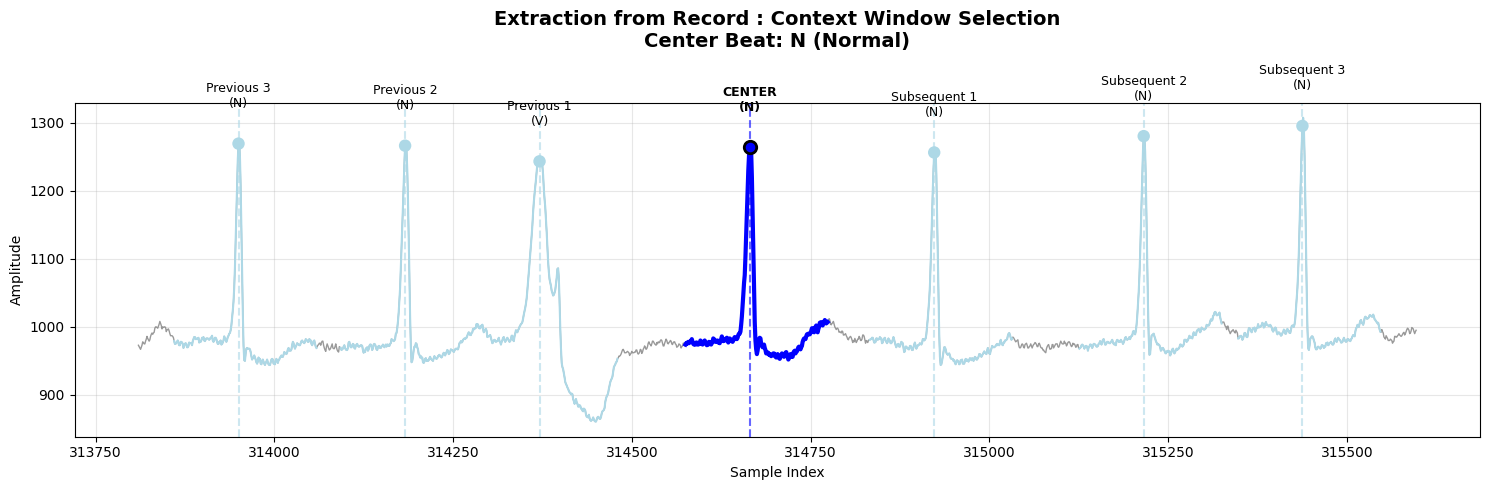

In [12]:
#original signal segments
plt.figure(figsize=(15, 5)) # Buat canvas baru

# Get the indices of beats in this context window
window_start_beat = center_beat_in_original - half_window
window_end_beat = center_beat_in_original + half_window + 1

# Get sample indices
window_beats_info = [(sample_annotations[i][0], sample_annotations[i][1], i) 
                     for i in range(window_start_beat, min(window_end_beat, len(sample_annotations)))]

# Signal range for this context window
sig_start = max(0, window_beats_info[0][0] - PRE_R_SAMPLES - 50)
sig_end = min(len(sample_signal), window_beats_info[-1][0] + POST_R_SAMPLES + 50)

x_axis_cw = np.arange(sig_start, sig_end)
plt.plot(x_axis_cw, sample_signal[sig_start:sig_end], 'gray', linewidth=1, alpha=0.8)

# Color beats based on their position in context window
beat_colors = ['lightblue'] * half_window + ['blue'] + ['lightblue'] * half_window
beat_labels_cw = [f'Previous {half_window - i}' for i in range(half_window)] + ['CENTER'] + \
                 [f'Subsequent {i + 1}' for i in range(half_window)]

for idx, (sample_idx, beat_type, original_idx) in enumerate(window_beats_info):
    color = beat_colors[idx]
    linewidth = 3 if idx == half_window else 1.5  # Thicker for center beat
    
    beat_start = sample_idx - PRE_R_SAMPLES
    beat_end = sample_idx + POST_R_SAMPLES
    x_range = np.arange(max(beat_start, sig_start), min(beat_end, sig_end))
    y_range = sample_signal[max(beat_start, sig_start):min(beat_end, sig_end)]
    
    plt.plot(x_range, y_range, color=color, linewidth=linewidth)
    plt.axvline(x=sample_idx, color=color, linestyle='--', alpha=0.6)
    plt.scatter([sample_idx], [sample_signal[sample_idx]], color=color, s=80, zorder=5,
               edgecolor='black' if idx == half_window else 'none', linewidth=2)
    
    label_y = sample_signal[sample_idx] + 0.12 * (np.max(sample_signal[sig_start:sig_end]) - np.min(sample_signal[sig_start:sig_end]))
    plt.text(sample_idx, label_y, f'{beat_labels_cw[idx]}\n({beat_type})', 
             ha='center', fontsize=9, fontweight='bold' if idx == half_window else 'normal')

center_label_text = 'Normal' if sample_label == 0 else 'Abnormal'
plt.title(f'Extraction from Record : Context Window Selection\n'
          f'Center Beat: {sample_beat_type} ({center_label_text})', fontsize=14, fontweight='bold', pad =40 )
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure_1_signal_extraction.png', dpi=300)
plt.show()

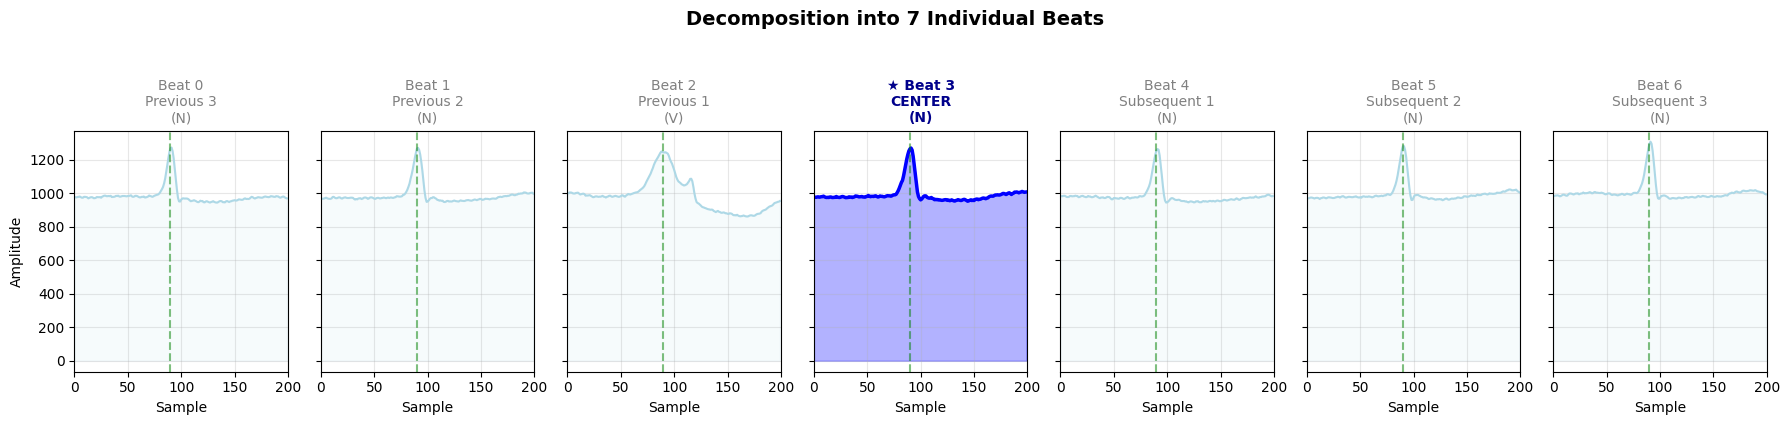

In [13]:
#indidvidual beats subplots
fig, axes = plt.subplots(1, 7, figsize=(18, 4), sharey=True) # 1 baris, 7 kolom

for beat_idx in range(CONTEXT_WINDOW_SIZE):
    ax = axes[beat_idx]
    beat = sample_cw[beat_idx]
    
    is_center = beat_idx == half_window
    color = 'blue' if is_center else 'lightblue'
    linewidth = 2.5 if is_center else 1.5
    
    ax.plot(beat, color=color, linewidth=linewidth)
    ax.axvline(x=PRE_R_SAMPLES, color='green', linestyle='--', alpha=0.5)
    ax.fill_between(range(len(beat)), beat, alpha=0.3 if is_center else 0.1, color=color)
    
    beat_type_cw = sample_annotations[window_start_beat + beat_idx][1]
    title_prefix = '★ ' if is_center else ''
    
    # Judul per kotak kecil
    ax.set_title(f'{title_prefix}Beat {beat_idx}\n{beat_labels_cw[beat_idx]}\n({beat_type_cw})', 
                 fontsize=10, fontweight='bold' if is_center else 'normal', 
                 color='darkblue' if is_center else 'gray')
    
    if beat_idx == 0:
        ax.set_ylabel('Amplitude')
    ax.set_xlabel('Sample')
    ax.set_xlim(0, BEAT_LENGTH)
    ax.grid(True, alpha=0.3)

plt.suptitle('Decomposition into 7 Individual Beats', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figure_2_individual_beats.png', dpi=300)
plt.show()

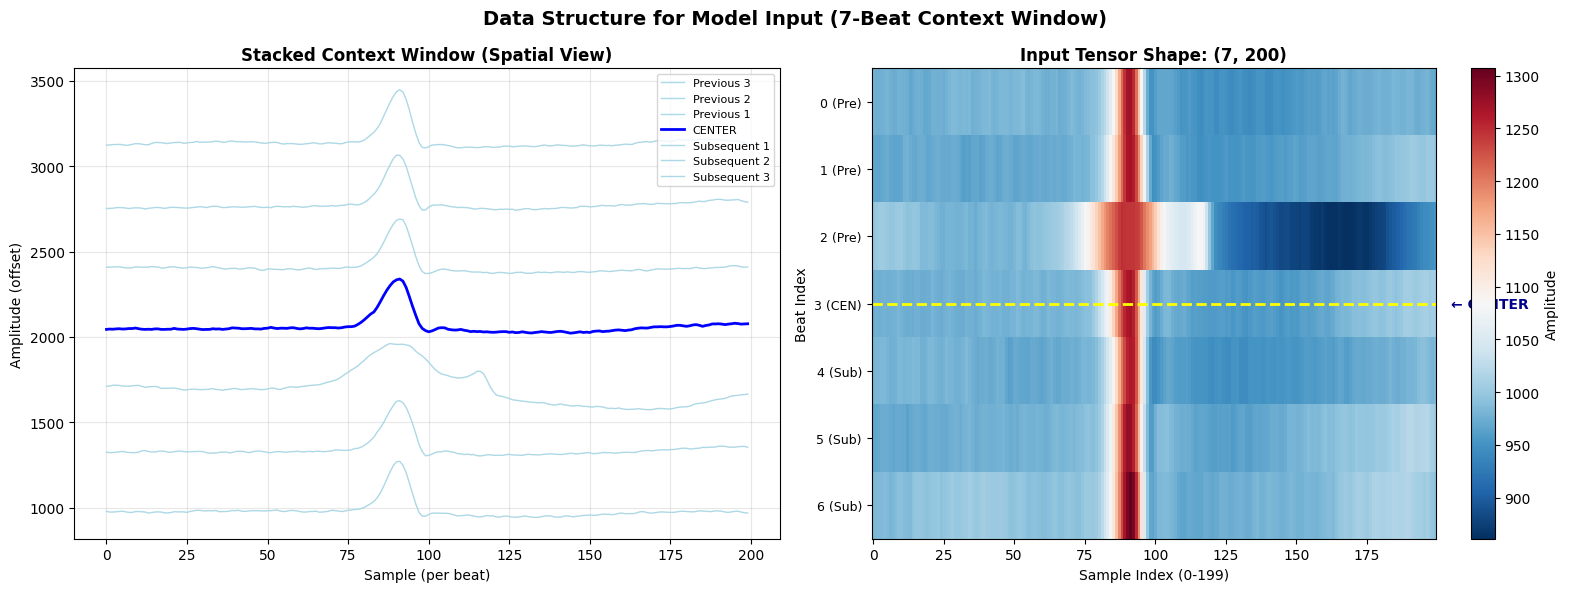

In [14]:
#picture 3: STACKED & HEATMAP (INPUT MODEL EPRESENTATION)
fig, (ax_stacked, ax_array) = plt.subplots(1, 2, figsize=(16, 6))

# left subplot (Stacked Lines)
offset = 0
offset_step = 0.8 * (np.max(sample_cw) - np.min(sample_cw))

for beat_idx in range(CONTEXT_WINDOW_SIZE):
    beat = sample_cw[beat_idx]
    is_center = beat_idx == half_window
    color = 'blue' if is_center else 'lightblue'
    linewidth = 2 if is_center else 1
    
    ax_stacked.plot(beat + offset, color=color, linewidth=linewidth, 
                    label=f'{beat_labels_cw[beat_idx]}')
    offset += offset_step

ax_stacked.set_title('Stacked Context Window (Spatial View)', fontsize=12, fontweight='bold')
ax_stacked.set_xlabel('Sample (per beat)')
ax_stacked.set_ylabel('Amplitude (offset)')
ax_stacked.legend(loc='upper right', fontsize=8)
ax_stacked.grid(True, alpha=0.3)

#heatmap array (right)
im = ax_array.imshow(sample_cw, aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax_array.set_title(f'Input Tensor Shape: ({CONTEXT_WINDOW_SIZE}, {BEAT_LENGTH})', 
                   fontsize=12, fontweight='bold')
ax_array.set_xlabel('Sample Index (0-199)')
ax_array.set_ylabel('Beat Index')
ax_array.set_yticks(range(CONTEXT_WINDOW_SIZE))
ax_array.set_yticklabels([f'{i} ({beat_labels_cw[i][:3]})' for i in range(CONTEXT_WINDOW_SIZE)], fontsize=9)
plt.colorbar(im, ax=ax_array, label='Amplitude')

#center beat marking
ax_array.axhline(y=half_window, color='yellow', linewidth=2, linestyle='--')
ax_array.text(BEAT_LENGTH + 5, half_window, '← CENTER', fontsize=10, va='center', fontweight='bold', color='darkblue')

plt.suptitle('Data Structure for Model Input (7-Beat Context Window)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_3_model_input.png', dpi=300)
plt.show()

## STEP 8: Process All Records

In [15]:
# Process all records and create context windows
all_record_data = {}  # record_id to list of context windows
record_stats = []

print('Processing MIT-BIH records...')
print('=' * 70)

for signal_file in signal_files:
    record_name = os.path.basename(signal_file).replace('.csv', '')
    
    # Skip excluded records
    if record_name in EXCLUDE_RECORDS:
        print(f'Skipping {record_name} (reserved for testing)')
        continue
    
    # Find annotation file
    annotation_file = os.path.join(DATA_PATH, f'{record_name}annotations.txt')
    if not os.path.exists(annotation_file):
        # Try alternative naming
        annotation_file = os.path.join(DATA_PATH, f'a{record_name}annotations.txt')
        if not os.path.exists(annotation_file):
            print(f'No annotation file for {record_name}, skipping')
            continue
    
    # Process record to get individual beats
    beats_data = process_record(signal_file, annotation_file)
    
    if len(beats_data) < CONTEXT_WINDOW_SIZE:
        print(f'Record {record_name}: Too few beats ({len(beats_data)}), skipping')
        continue
    
    # Create context windows
    context_windows = create_context_windows(beats_data)
    
    if len(context_windows) > 0:
        n_normal = sum(1 for _, label, _ in context_windows if label == 0)
        n_abnormal = len(context_windows) - n_normal
        
        print(f'Record {record_name}: {len(context_windows)} context windows '
              f'(Normal: {n_normal}, Abnormal: {n_abnormal})')
        
        all_record_data[record_name] = context_windows
        record_stats.append({
            'record': record_name,
            'total_windows': len(context_windows),
            'normal': n_normal,
            'abnormal': n_abnormal
        })

print('\n' + '=' * 70)
print(f'Processed {len(all_record_data)} records')
total_windows = sum(len(cw) for cw in all_record_data.values())
print(f'Total context windows: {total_windows}')

Processing MIT-BIH records...
Record 100: 2267 context windows (Normal: 2233, Abnormal: 34)
Record 101: 1859 context windows (Normal: 1854, Abnormal: 5)
Record 102: 2181 context windows (Normal: 99, Abnormal: 2082)
Record 103: 2078 context windows (Normal: 2076, Abnormal: 2)
Record 104: 2223 context windows (Normal: 163, Abnormal: 2060)
Record 105: 2566 context windows (Normal: 2520, Abnormal: 46)
Record 106: 2021 context windows (Normal: 1503, Abnormal: 518)
Record 107: 2131 context windows (Normal: 0, Abnormal: 2131)
Record 108: 1768 context windows (Normal: 1733, Abnormal: 35)
Record 109: 2526 context windows (Normal: 0, Abnormal: 2526)
Record 111: 2118 context windows (Normal: 0, Abnormal: 2118)
Record 112: 2533 context windows (Normal: 2531, Abnormal: 2)
Record 113: 1789 context windows (Normal: 1783, Abnormal: 6)
Record 114: 1873 context windows (Normal: 1814, Abnormal: 59)
Record 115: 1947 context windows (Normal: 1947, Abnormal: 0)
Record 116: 2406 context windows (Normal: 2296

## STEP 9: Record-Wise Train/Val/Test Split

In [16]:
# Split records (not beats) into train/val/test
#to ensures no patient leakage

all_records = list(all_record_data.keys())
np.random.shuffle(all_records)

n_records = len(all_records)
n_train = int(0.7 * n_records)
n_val = int(0.15 * n_records)
n_test = n_records - n_train - n_val

train_records = all_records[:n_train]
val_records = all_records[n_train:n_train + n_val]
test_records = all_records[n_train + n_val:]

print('Record-Wise Split (No Patient Leakage):')
print('=' * 50)
print(f'Train records ({len(train_records)}): {train_records}')
print(f'Val records ({len(val_records)}): {val_records}')
print(f'Test records ({len(test_records)}): {test_records}')

# Verify no overlap
assert len(set(train_records) & set(val_records)) == 0, 'Train/Val overlap!'
assert len(set(train_records) & set(test_records)) == 0, 'Train/Test overlap!'
assert len(set(val_records) & set(test_records)) == 0, 'Val/Test overlap!'
print('\nVerified: No overlap between splits')

Record-Wise Split (No Patient Leakage):
Train records (32): ['207', '223', '205', '231', '202', '220', '113', '122', '104', '203', '108', '103', '106', '222', '214', '114', '118', '233', '116', '109', '117', '209', '213', '234', '100', '212', '210', '105', '112', '215', '101', '232']
Val records (7): ['124', '102', '219', '217', '201', '228', '111']
Test records (8): ['200', '121', '221', '123', '107', '230', '115', '208']

Verified: No overlap between splits


### Visualization: Record-Wise Split Distribution (Step 9)

Pie chart showing:
1. **Outer ring**: Record-wise split percentages (Train/Val/Test)
2. **Inner details**: Normal/Abnormal distribution within each split

Split Statistics:
Train: 75804 windows (70.3%) - Normal: 54685, Abnormal: 21119
Val: 14436 windows (13.4%) - Normal: 5722, Abnormal: 8714
Test: 17662 windows (16.4%) - Normal: 12908, Abnormal: 4754


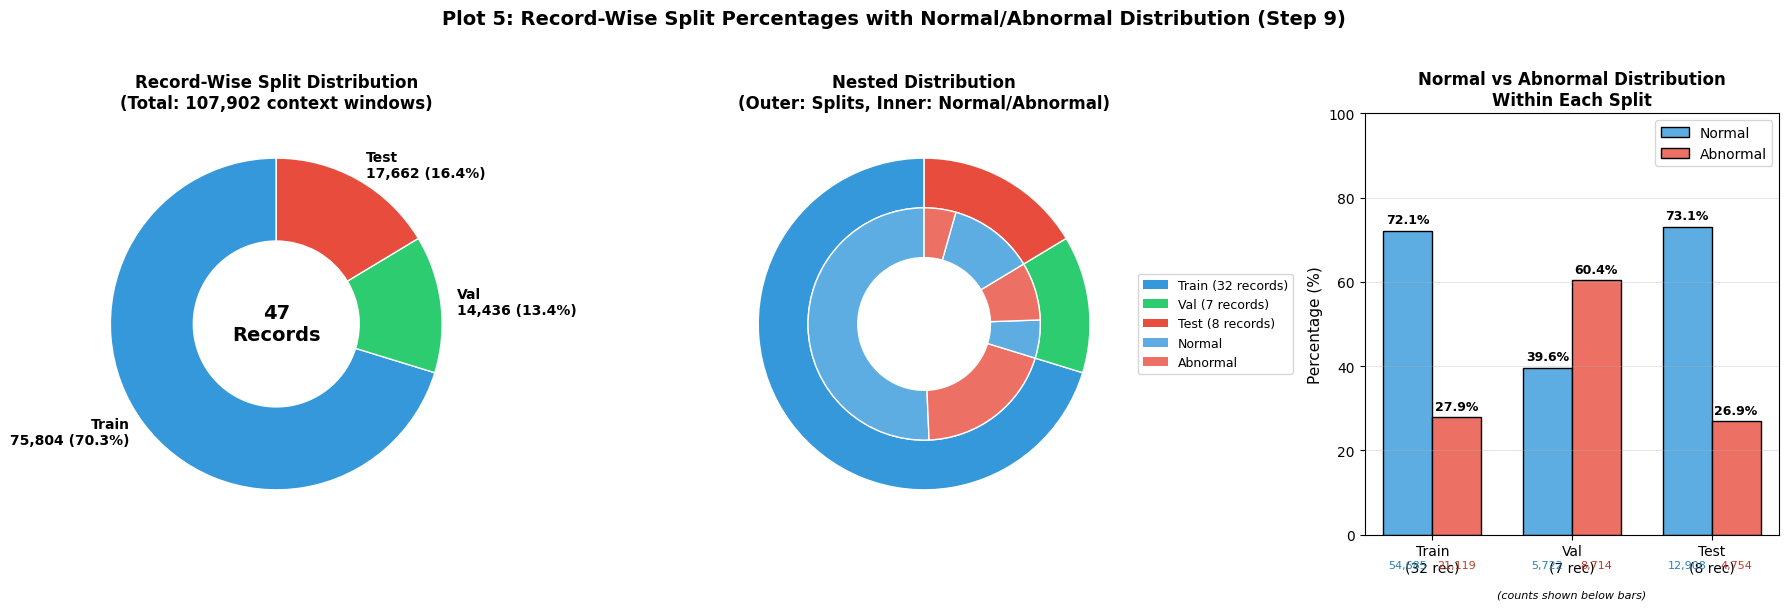


Visualization saved to: split_distribution_pie_chart.png


In [17]:
# Visualization: Record-Wise Split Distribution (Step 9)

# Calculate statistics for each split
def get_split_stats(record_list, all_data):
    total_windows = 0
    total_normal = 0
    total_abnormal = 0
    
    for record in record_list:
        if record in all_data:
            for _, label, _ in all_data[record]:
                total_windows += 1
                if label == 0:
                    total_normal += 1
                else:
                    total_abnormal += 1
    
    return total_windows, total_normal, total_abnormal

train_total, train_normal, train_abnormal = get_split_stats(train_records, all_record_data)
val_total, val_normal, val_abnormal = get_split_stats(val_records, all_record_data)
test_total, test_normal, test_abnormal = get_split_stats(test_records, all_record_data)

total_all = train_total + val_total + test_total

print('Split Statistics:')
print(f'Train: {train_total} windows ({train_total/total_all*100:.1f}%) - Normal: {train_normal}, Abnormal: {train_abnormal}')
print(f'Val: {val_total} windows ({val_total/total_all*100:.1f}%) - Normal: {val_normal}, Abnormal: {val_abnormal}')
print(f'Test: {test_total} windows ({test_total/total_all*100:.1f}%) - Normal: {test_normal}, Abnormal: {test_abnormal}')

# Create pie chart with nested structure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Split colors
split_colors = {'Train': '#3498db', 'Val': '#2ecc71', 'Test': '#e74c3c'}
class_colors = {'Normal': '#5dade2', 'Abnormal': '#ec7063'}

#main split
ax1 = axes[0]
split_sizes = [train_total, val_total, test_total]
split_labels = [f'Train\n{train_total:,} ({train_total/total_all*100:.1f}%)',
                f'Val\n{val_total:,} ({val_total/total_all*100:.1f}%)',
                f'Test\n{test_total:,} ({test_total/total_all*100:.1f}%)']

wedges1, texts1, autotexts1 = ax1.pie(split_sizes, labels=split_labels, 
                                       colors=[split_colors['Train'], split_colors['Val'], split_colors['Test']],
                                       autopct='', startangle=90, 
                                       wedgeprops=dict(width=0.5, edgecolor='white'),
                                       textprops={'fontsize': 10, 'fontweight': 'bold'})

ax1.set_title(f'Record-Wise Split Distribution\n(Total: {total_all:,} context windows)', 
              fontsize=12, fontweight='bold')

# Add center text
ax1.text(0, 0, f'{len(train_records)+len(val_records)+len(test_records)}\nRecords', 
         ha='center', va='center', fontsize=14, fontweight='bold')

ax2 = axes[1]

# Outer ring: splits
outer_sizes = [train_total, val_total, test_total]
outer_colors = [split_colors['Train'], split_colors['Val'], split_colors['Test']]

# Inner ring: Normal/Abnormal for each split
inner_sizes = [train_normal, train_abnormal, val_normal, val_abnormal, test_normal, test_abnormal]
inner_colors = ['#aed6f1', '#f5b7b1', '#a9dfbf', '#f5b7b1', '#fadbd8', '#f5b7b1']

# Create nested pie
wedges_outer, texts_outer = ax2.pie(outer_sizes, radius=1.0, 
                                     colors=outer_colors,
                                     wedgeprops=dict(width=0.3, edgecolor='white'),
                                     startangle=90)

# Calculate angles for inner pie
inner_sizes_normalized = []
for i, (total, normal, abnormal) in enumerate([(train_total, train_normal, train_abnormal),
                                                 (val_total, val_normal, val_abnormal),
                                                 (test_total, test_normal, test_abnormal)]):
    inner_sizes_normalized.extend([normal, abnormal])

inner_colors_final = []
for split_name in ['Train', 'Val', 'Test']:
    inner_colors_final.extend(['#5dade2', '#ec7063'])  # Blue for Normal, Red for Abnormal

wedges_inner, texts_inner = ax2.pie(inner_sizes_normalized, radius=0.7,
                                     colors=inner_colors_final,
                                     wedgeprops=dict(width=0.3, edgecolor='white'),
                                     startangle=90)

ax2.set_title('Nested Distribution\n(Outer: Splits, Inner: Normal/Abnormal)', 
              fontsize=12, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=split_colors['Train'], label=f'Train ({len(train_records)} records)'),
    Patch(facecolor=split_colors['Val'], label=f'Val ({len(val_records)} records)'),
    Patch(facecolor=split_colors['Test'], label=f'Test ({len(test_records)} records)'),
    Patch(facecolor='#5dade2', label='Normal'),
    Patch(facecolor='#ec7063', label='Abnormal'),
]
ax2.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)


ax3 = axes[2]

splits = ['Train', 'Val', 'Test']
normal_pcts = [train_normal/train_total*100, val_normal/val_total*100, test_normal/test_total*100]
abnormal_pcts = [train_abnormal/train_total*100, val_abnormal/val_total*100, test_abnormal/test_total*100]

x = np.arange(len(splits))
width = 0.35

bars1 = ax3.bar(x - width/2, normal_pcts, width, label='Normal', color='#5dade2', edgecolor='black')
bars2 = ax3.bar(x + width/2, abnormal_pcts, width, label='Abnormal', color='#ec7063', edgecolor='black')

ax3.set_ylabel('Percentage (%)', fontsize=11)
ax3.set_title('Normal vs Abnormal Distribution\nWithin Each Split', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'{s}\n({n} rec)' for s, n in zip(splits, [len(train_records), len(val_records), len(test_records)])],
                    fontsize=10)
ax3.legend(loc='upper right', fontsize=10)
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars, values in [(bars1, normal_pcts), (bars2, abnormal_pcts)]:
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax3.annotate(f'{val:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add counts below bars
for i, (split, normal, abnormal) in enumerate([(splits[0], train_normal, train_abnormal),
                                                (splits[1], val_normal, val_abnormal),
                                                (splits[2], test_normal, test_abnormal)]):
    ax3.text(i - width/2, -8, f'{normal:,}', ha='center', fontsize=8, color='#2980b9')
    ax3.text(i + width/2, -8, f'{abnormal:,}', ha='center', fontsize=8, color='#c0392b')

ax3.text(0.5, -0.15, '(counts shown below bars)', transform=ax3.transAxes, 
         ha='center', fontsize=8, style='italic')

plt.suptitle('Plot 5: Record-Wise Split Percentages with Normal/Abnormal Distribution (Step 9)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('split_distribution_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nVisualization saved to: split_distribution_pie_chart.png')

## STEP 10: Collect Data for Each Split

In [18]:
def collect_split_data(record_list, all_data):

    X_list = []
    y_list = []
    
    for record in record_list:
        if record in all_data:
            for context_window, label, _ in all_data[record]:
                X_list.append(context_window)
                y_list.append(label)
    
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    
    return X, y


# Collect data for each split
X_train, y_train = collect_split_data(train_records, all_record_data)
X_val, y_val = collect_split_data(val_records, all_record_data)
X_test, y_test = collect_split_data(test_records, all_record_data)

print('Data Collected:')
print('=' * 50)
print(f'Train: X={X_train.shape}, y={y_train.shape}')
print(f'  Normal: {np.sum(y_train == 0)}, Abnormal: {np.sum(y_train == 1)}')
print(f'Val: X={X_val.shape}, y={y_val.shape}')
print(f'  Normal: {np.sum(y_val == 0)}, Abnormal: {np.sum(y_val == 1)}')
print(f'Test: X={X_test.shape}, y={y_test.shape}')
print(f'  Normal: {np.sum(y_test == 0)}, Abnormal: {np.sum(y_test == 1)}')

Data Collected:
Train: X=(75804, 7, 200), y=(75804,)
  Normal: 54685, Abnormal: 21119
Val: X=(14436, 7, 200), y=(14436,)
  Normal: 5722, Abnormal: 8714
Test: X=(17662, 7, 200), y=(17662,)
  Normal: 12908, Abnormal: 4754


## STEP 11: Data Quality Checks

In [19]:
print('Data Quality Checks')
print('=' * 50)

# Check for NaN values
train_nan = np.isnan(X_train).sum()
val_nan = np.isnan(X_val).sum()
test_nan = np.isnan(X_test).sum()
print(f'NaN values - Train: {train_nan}, Val: {val_nan}, Test: {test_nan}')

# Check for infinite values
train_inf = np.isinf(X_train).sum()
val_inf = np.isinf(X_val).sum()
test_inf = np.isinf(X_test).sum()
print(f'Infinite values - Train: {train_inf}, Val: {val_inf}, Test: {test_inf}')

# Check data ranges
print(f'\nTrain data range: [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'Val data range: [{X_val.min():.2f}, {X_val.max():.2f}]')
print(f'Test data range: [{X_test.min():.2f}, {X_test.max():.2f}]')

# Check shape
expected_shape = (CONTEXT_WINDOW_SIZE, BEAT_LENGTH)
print(f'\nExpected sample shape: {expected_shape}')
print(f'Actual sample shape: {X_train[0].shape}')
assert X_train[0].shape == expected_shape, 'Incorrect sample shape!'
print('Sample shape verified')

Data Quality Checks
NaN values - Train: 0, Val: 0, Test: 0
Infinite values - Train: 0, Val: 0, Test: 0

Train data range: [0.00, 2047.00]
Val data range: [303.00, 1704.00]
Test data range: [0.00, 1754.00]

Expected sample shape: (7, 200)
Actual sample shape: (7, 200)
Sample shape verified


## STEP 12: Visualize Sample Context Windows

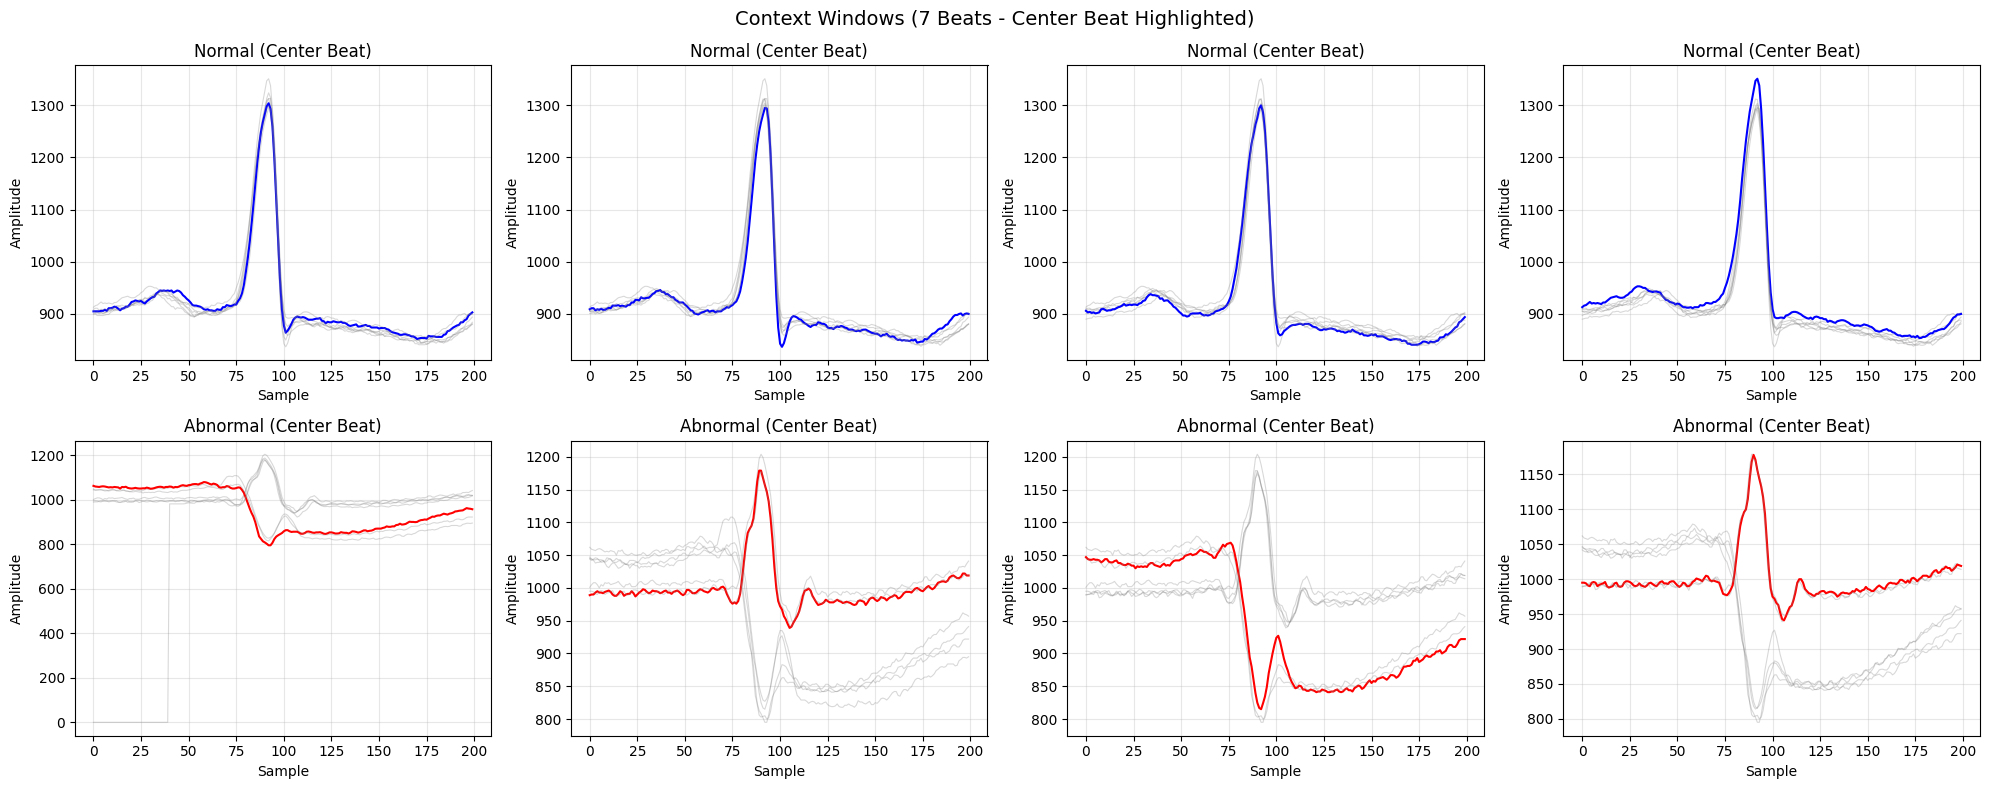

Visualization saved to: context_windows_visualization.png


In [20]:
import matplotlib.pyplot as plt

# Sample context windows
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Get sample normal and abnormal windows
normal_idx = np.where(y_train == 0)[0][:4]
abnormal_idx = np.where(y_train == 1)[0][:4]

for i, idx in enumerate(normal_idx):
    if i >= 4:
        break
    ax = axes[0, i]
    context = X_train[idx]
    for beat_idx in range(CONTEXT_WINDOW_SIZE):
        alpha = 0.3 if beat_idx != 3 else 1.0  # Highlight center beat
        color = 'blue' if beat_idx == 3 else 'gray'
        ax.plot(context[beat_idx], alpha=alpha, color=color, linewidth=1.5 if beat_idx == 3 else 0.8)
    ax.set_title(f'Normal (Center Beat)')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

for i, idx in enumerate(abnormal_idx):
    if i >= 4:
        break
    ax = axes[1, i]
    context = X_train[idx]
    for beat_idx in range(CONTEXT_WINDOW_SIZE):
        alpha = 0.3 if beat_idx != 3 else 1.0
        color = 'red' if beat_idx == 3 else 'gray'
        ax.plot(context[beat_idx], alpha=alpha, color=color, linewidth=1.5 if beat_idx == 3 else 0.8)
    ax.set_title(f'Abnormal (Center Beat)')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

plt.suptitle('Context Windows (7 Beats - Center Beat Highlighted)', fontsize=14)
plt.tight_layout()
plt.savefig('context_windows_visualization.png', dpi=150)
plt.show()

print('Visualization saved to: context_windows_visualization.png')

## STEP 13: Save Output Files

In [21]:
# Output directory
output_dir = '/kaggle/working/' if os.path.exists('/kaggle/working/') else './'

# Save numpy arrays
np.save(os.path.join(output_dir, 'X_train.npy'), X_train)
np.save(os.path.join(output_dir, 'y_train.npy'), y_train)
np.save(os.path.join(output_dir, 'X_val.npy'), X_val)
np.save(os.path.join(output_dir, 'y_val.npy'), y_val)
np.save(os.path.join(output_dir, 'X_test.npy'), X_test)
np.save(os.path.join(output_dir, 'y_test.npy'), y_test)

print('Saved numpy arrays:')
print(f'  X_train.npy: {X_train.shape}')
print(f'  y_train.npy: {y_train.shape}')
print(f'  X_val.npy: {X_val.shape}')
print(f'  y_val.npy: {y_val.shape}')
print(f'  X_test.npy: {X_test.shape}')
print(f'  y_test.npy: {y_test.shape}')

# Save record split
record_split = {
    'train': train_records,
    'val': val_records,
    'test': test_records
}
with open(os.path.join(output_dir, 'record_split.json'), 'w') as f:
    json.dump(record_split, f, indent=2)
print('\nSaved record_split.json')

# Save dataset config
dataset_config = {
    'beat_length': BEAT_LENGTH,
    'pre_r_samples': PRE_R_SAMPLES,
    'post_r_samples': POST_R_SAMPLES,
    'context_window_size': CONTEXT_WINDOW_SIZE,
    'sampling_rate': SAMPLING_RATE,
    'excluded_records': EXCLUDE_RECORDS,
    'label_mapping': {
        '0': 'Normal (N)',
        '1': 'Abnormal (non-N)'
    },
    'train_samples': int(len(X_train)),
    'val_samples': int(len(X_val)),
    'test_samples': int(len(X_test)),
    'train_normal': int(np.sum(y_train == 0)),
    'train_abnormal': int(np.sum(y_train == 1)),
    'val_normal': int(np.sum(y_val == 0)),
    'val_abnormal': int(np.sum(y_val == 1)),
    'test_normal': int(np.sum(y_test == 0)),
    'test_abnormal': int(np.sum(y_test == 1)),
    'random_state': RANDOM_STATE
}
with open(os.path.join(output_dir, 'dataset_config.json'), 'w') as f:
    json.dump(dataset_config, f, indent=2)
print('Saved dataset_config.json')

Saved numpy arrays:
  X_train.npy: (75804, 7, 200)
  y_train.npy: (75804,)
  X_val.npy: (14436, 7, 200)
  y_val.npy: (14436,)
  X_test.npy: (17662, 7, 200)
  y_test.npy: (17662,)

Saved record_split.json
Saved dataset_config.json


## STEP 14: Summary

In [22]:
print('=' * 70)
print('CONTEXT-AWARE DATASET CREATION SUMMARY')
print('=' * 70)

print(f'\n1. INPUT:')
print(f'   - Source: MIT-BIH Arrhythmia Database')
print(f'   - Records processed: {len(all_record_data)}')
print(f'   - Records excluded: {EXCLUDE_RECORDS}')

print(f'\n2. CONTEXT WINDOW CONFIGURATION:')
print(f'   - Window size: {CONTEXT_WINDOW_SIZE} beats')
print(f'   - Structure: 3 previous + 1 center + 3 subsequent')
print(f'   - Beat length: {BEAT_LENGTH} samples')
print(f'   - Pre-R samples: {PRE_R_SAMPLES}')
print(f'   - Post-R samples: {POST_R_SAMPLES}')

print(f'\n3. RECORD-WISE SPLIT (No Patient Leakage):')
print(f'   - Train: {len(train_records)} records ({len(X_train)} windows)')
print(f'   - Val: {len(val_records)} records ({len(X_val)} windows)')
print(f'   - Test: {len(test_records)} records ({len(X_test)} windows)')

print(f'\n4. CLASS DISTRIBUTION:')
print(f'   Train: Normal={np.sum(y_train == 0)}, Abnormal={np.sum(y_train == 1)}')
print(f'   Val: Normal={np.sum(y_val == 0)}, Abnormal={np.sum(y_val == 1)}')
print(f'   Test: Normal={np.sum(y_test == 0)}, Abnormal={np.sum(y_test == 1)}')

print(f'\n5. OUTPUT FILES:')
print(f'   - X_train.npy, y_train.npy')
print(f'   - X_val.npy, y_val.npy')
print(f'   - X_test.npy, y_test.npy')
print(f'   - record_split.json')
print(f'   - dataset_config.json')

print(f'\n6. VALIDATION:')
print(f'   No patient leakage (record-wise split)')
print(f'   Context window strictly enforced ({CONTEXT_WINDOW_SIZE} beats)')
print(f'   Binary classification (Normal vs Abnormal)')
print(f'   Record 119 excluded (for live testing)')

print(f'\n7. NEXT STEPS:')
print(f'   - Run mitbih_context_cnn1d_training.ipynb')
print(f'   - Use output .npy files as input')
print(f'   - Normalize using training data statistics ONLY')

print('\n' + '=' * 70)
print('Dataset creation complete!')
print('=' * 70)

CONTEXT-AWARE DATASET CREATION SUMMARY

1. INPUT:
   - Source: MIT-BIH Arrhythmia Database
   - Records processed: 47
   - Records excluded: ['119']

2. CONTEXT WINDOW CONFIGURATION:
   - Window size: 7 beats
   - Structure: 3 previous + 1 center + 3 subsequent
   - Beat length: 200 samples
   - Pre-R samples: 90
   - Post-R samples: 110

3. RECORD-WISE SPLIT (No Patient Leakage):
   - Train: 32 records (75804 windows)
   - Val: 7 records (14436 windows)
   - Test: 8 records (17662 windows)

4. CLASS DISTRIBUTION:
   Train: Normal=54685, Abnormal=21119
   Val: Normal=5722, Abnormal=8714
   Test: Normal=12908, Abnormal=4754

5. OUTPUT FILES:
   - X_train.npy, y_train.npy
   - X_val.npy, y_val.npy
   - X_test.npy, y_test.npy
   - record_split.json
   - dataset_config.json

6. VALIDATION:
   No patient leakage (record-wise split)
   Context window strictly enforced (7 beats)
   Binary classification (Normal vs Abnormal)
   Record 119 excluded (for live testing)

7. NEXT STEPS:
   - Run mi

In [23]:
import os
import zipfile

working_dir = "/kaggle/working"
zip_path = "/kaggle/working/output.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(working_dir):
        for file in files:
            file_path = os.path.join(root, file)
            # avoid zipping the zip itself
            if file_path == zip_path:
                continue
            arcname = os.path.relpath(file_path, working_dir)
            zipf.write(file_path, arcname)

print(f"Zipped everything into: {zip_path}")


Zipped everything into: /kaggle/working/output.zip
